# Practical Statistics for Data Scientists (Python)
# Chapter 2. Data and Sampling Distributions
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

Import required Python packages.

In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt
from scipy.stats import norm

In [2]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [3]:
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'

Figure 2.1

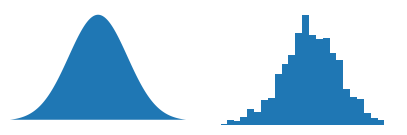

In [4]:
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

# Sampling Distribution of a Statistic

In [14]:
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')
print(type(loans_income))
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})
print(sample_mean_20.head())
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

<class 'pandas.core.series.Series'>
     income        type
0  73440.10  Mean of 20
1  63993.70  Mean of 20
2  64184.40  Mean of 20
3  85185.95  Mean of 20
4  82904.00  Mean of 20
         income  type
26710   43000.0  Data
3946   103000.0  Data
26166  115000.0  Data
37814   24000.0  Data
1565   125000.0  Data


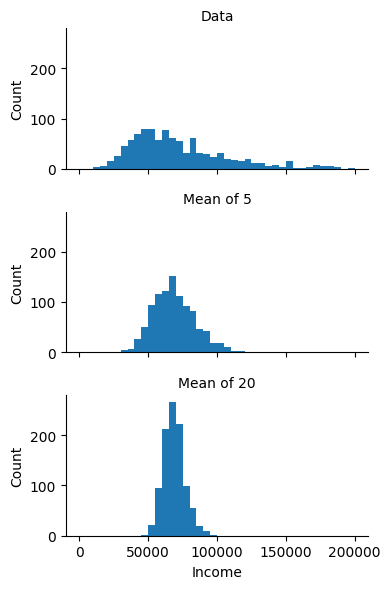

In [6]:
g = sns.FacetGrid(results, col='type', col_wrap=1, 
                  height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

# The Bootstrap

In [7]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -82.09799999999814
std. error: 228.73933106830927


# Confidence Intervals

68760.51844
55734.1


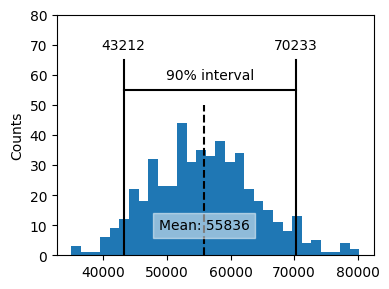

In [8]:
print(loans_income.mean())
np.random.seed(seed=3)  
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Counts')

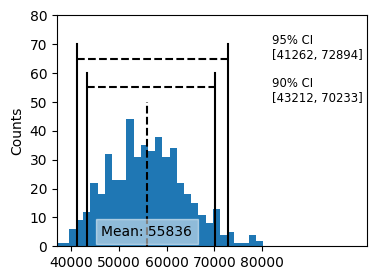

In [9]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color='C1')
ax.plot(confidence_interval, [55, 55], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color='black')
ax.text(82000, 50, 
        f'90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color='black')
ax.text(82000, 65, 
        f'95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')
# ax.text(sum(confidence_interval) / 2, 264, '95 % interval',
#         horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 5, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel('Counts')

# plt.tight_layout()
# plt.show()

# Normal Distribution
## Standard Normal and QQ-Plots
The package _scipy_ has the function (`scipy.stats.probplot`) to create QQ-plots. The argument `dist` specifies the distribution, which is set by default to the normal distribution.

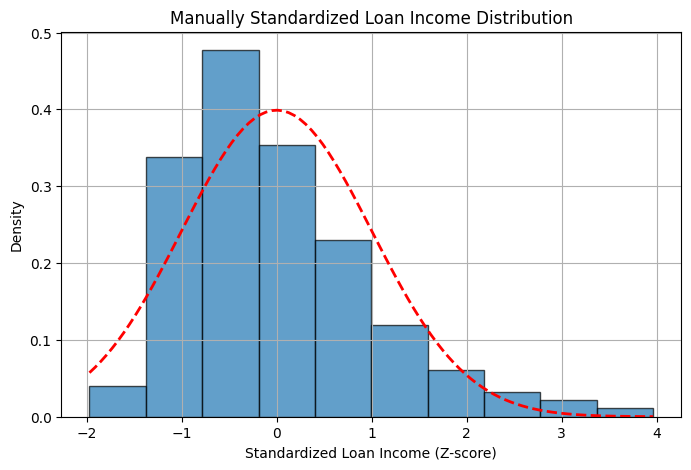

       loan_income  loan_income_standardized
0            67000                 -0.053557
1            52000                 -0.509872
2           100000                  0.950336
3            78762                  0.304255
4            37041                 -0.964939
...            ...                       ...
49995        40000                 -0.874924
49996        54000                 -0.449030
49997        50000                 -0.570714
49998        82000                  0.402758
49999        70000                  0.037706

[50000 rows x 2 columns]


In [19]:

loans = pd.DataFrame({
    'loan_income': loans_income
})

# --- Manual standardization ---
mean = loans['loan_income'].mean()
std = loans['loan_income'].std()
loans['loan_income_standardized'] = (loans['loan_income'] - mean) / std

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(loans['loan_income_standardized'], bins=10, density=True, edgecolor='black', alpha=0.7)

# Overlay normal distribution curve
x = np.linspace(loans['loan_income_standardized'].min(), loans['loan_income_standardized'].max(), 100)
plt.plot(x, norm.pdf(x, 0, 1), 'r--', linewidth=2)

plt.title('Manually Standardized Loan Income Distribution')
plt.xlabel('Standardized Loan Income (Z-score)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

print(loans)

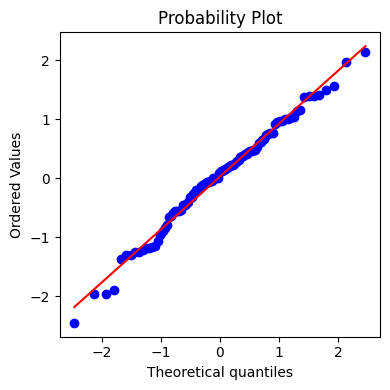

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)

plt.tight_layout()
plt.show()

# Long-Tailed Distributions

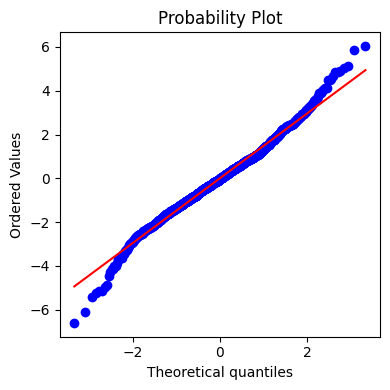

In [4]:
sp500_px = pd.read_csv(SP500_DATA_CSV)

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx>0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)

plt.tight_layout()
plt.show()

The Q–Q plot you showed earlier compared the raw data to a normal distribution and found:
	•	Normal in the middle,
	•	But with long tails (more extremes).

That’s consistent with the top histogram here (“Data”).
When you take means of several observations (middle and bottom plots), those tails shrink — which is exactly why sample statistics (like means) tend to follow the normal distribution even when the raw data do not.

✅ In summary
	•	The Q–Q plot showed: raw Netflix returns have heavy tails → not normally distributed.
	•	The histograms show: when you take averages of those returns, the distribution becomes normal-like.
	•	This demonstrates how the Central Limit Theorem explains why normal distributions are often used in statistics even though raw data themselves are rarely normal.

In [22]:
nflx_pd=pd.Series(nflx)
nflx_pd

0       0.194152
1      -0.287679
2      -0.125163
3      -0.405465
4       0.624154
          ...   
1607   -2.421733
1608    2.708029
1609   -0.338977
1610   -0.297474
1611   -0.389834
Length: 1612, dtype: float64

In [23]:
nflx_sample_data = pd.DataFrame({
    'stk_returns': nflx_pd.sample(1000),
    'type': 'Data',
})

nflx_sample_mean_05 = pd.DataFrame({
    'stk_returns': [nflx_pd.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

nflx_sample_mean_20 = pd.DataFrame({
    'stk_returns': [nflx_pd.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})
print(nflx_sample_mean_20.head())
nflx_results = pd.concat([nflx_sample_data, nflx_sample_mean_05, nflx_sample_mean_20])
print(nflx_results.head())

   stk_returns        type
0    -0.110481  Mean of 20
1    -0.469654  Mean of 20
2     0.316534  Mean of 20
3     0.244756  Mean of 20
4     0.042855  Mean of 20
      stk_returns  type
1346    -2.956042  Data
1399    -0.692001  Data
1335     2.255392  Data
1380    -0.941699  Data
1195     1.283792  Data


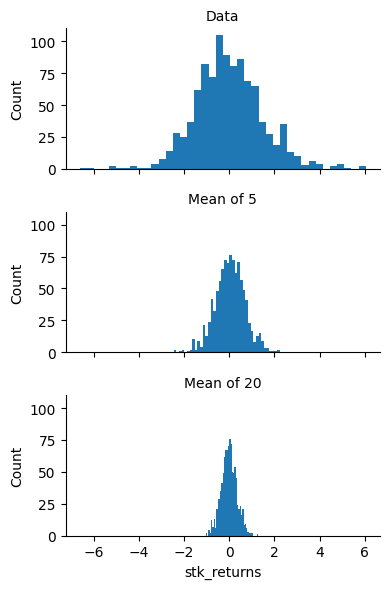

In [20]:
nflx_g = sns.FacetGrid(nflx_results, col='type', col_wrap=1, 
                  height=2, aspect=2)
nflx_g.map(plt.hist, 'stk_returns', bins=40)
nflx_g.set_axis_labels('stk_returns', 'Count')
nflx_g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

# Binomial Distribution

In [12]:
print(stats.binom.pmf(2, n=5, p=0.1))

0.0728999999999999


In [13]:
print(stats.binom.cdf(2, n=5, p=0.1))

0.99144


# Poisson and Related Distribution
## Poisson Distributions

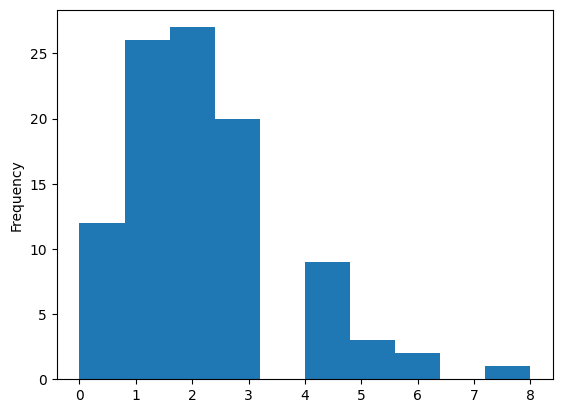

In [14]:
sample = stats.poisson.rvs(2, size=100)

pd.Series(sample).plot.hist()
plt.show()

## Exponential Distribution

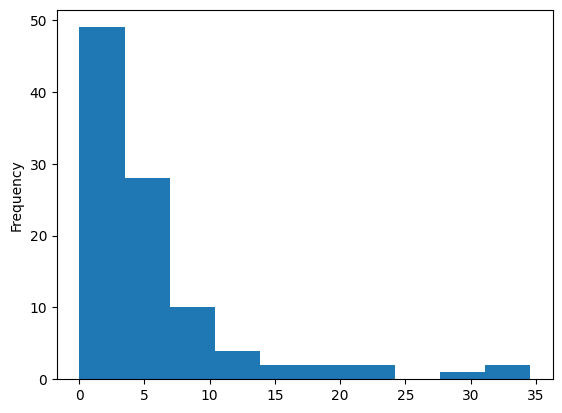

In [15]:
sample = stats.expon.rvs(scale=5, size=100)

pd.Series(sample).plot.hist()
plt.show()

##  Weibull Distribution

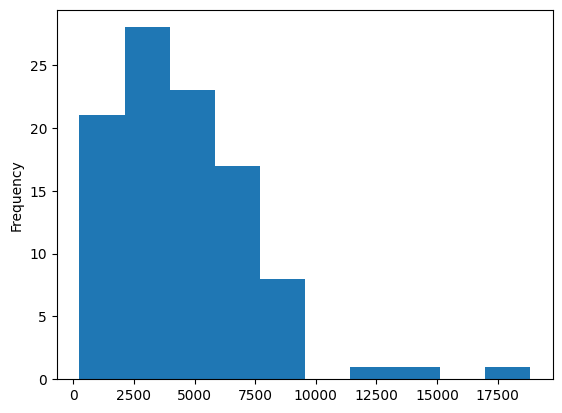

In [16]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

pd.Series(sample).plot.hist()
plt.show()